# 📊 Sales Data Analysis Project
## Objective
This project focuses on analyzing a real-world sales dataset to uncover meaningful business insights, identify performance trends, and evaluate profitability across different dimensions such as regions, categories, and products.
## 📦 Dataset Overview
The dataset contains transactional sales data including:
- Sales, Profit, Quantity
- Product Categories and Sub-Categories
- Customer Segments
- Regions and Locations
- Order and Shipping Dates
- Returns and Payment Modes
## 🎯 Key Questions
- Which regions and categories drive the most revenue?
- Are there loss-making products?
- Do discounts/returns affect profitability?
- What trends exist over time?
- What relationships exist between sales, profit, and quantity?

## Executive Summary
This analysis identifies key drivers of sales and profitability across regions, categories, and customer segments. Results show that while revenue is growing, profitability is inconsistent and influenced more by pricing and cost structures than by sales volume. High-performing areas such as Technology and Consumer segments drive profits, while specific sub-categories contribute disproportionately to losses.

In [1]:
from tempfile import template

# ================================
# 📦 1. IMPORT LIBRARIES
# ================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.patches as patches
import plotly.express as px
import plotly.graph_objects as go
import plotly.io as pio

In [2]:
# ================================
# 📂 2. LOAD DATA
# ================================
df = pd.read_csv(r"C:\Users\abc\PycharmProjects\Python Basic(Part 1)\notebooks\sales_analysis\data\processed\cleaned_sales_data.csv")

In [3]:
# ================================
# 🔍 3. BASIC INFO & OVERVIEW
# ================================
print(df.shape)
print(df.info())
print(df.describe())

(5901, 20)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5901 entries, 0 to 5900
Data columns (total 20 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   order_id       5901 non-null   object 
 1   order_date     5901 non-null   object 
 2   ship_date      5901 non-null   object 
 3   ship_mode      5901 non-null   object 
 4   customer_id    5901 non-null   object 
 5   customer_name  5901 non-null   object 
 6   segment        5901 non-null   object 
 7   country        5901 non-null   object 
 8   city           5901 non-null   object 
 9   state          5901 non-null   object 
 10  region         5901 non-null   object 
 11  product_id     5901 non-null   object 
 12  category       5901 non-null   object 
 13  sub_category   5901 non-null   object 
 14  product_name   5901 non-null   object 
 15  sales          5901 non-null   float64
 16  quantity       5901 non-null   int64  
 17  profit         5901 non-null   float64
 1

## Data Insights
The dataset consists of 5,901 records with no missing values, indicating high data quality and reliability for analysis. Sales and profit exhibit substantial variability, as reflected by their high standard deviations compared to their means, suggesting the presence of extreme values and inconsistent transaction sizes. Notably, the minimum profit is significantly negative (-6599.98), indicating that certain transactions are generating substantial losses. In contrast, the average return rate is relatively low (approximately 4.8%), implying effective return management. Additionally, the quantity purchased per order remains relatively stable, indicating that fluctuations in sales are more likely driven by price variations rather than changes in purchase volume.

## Business Implications
The presence of extreme negative profit values highlights the need for a detailed profitability analysis to identify loss-making products, regions, or pricing strategies. High variability in sales and profit suggests instability in revenue generation, emphasizing the importance of developing strategies to achieve more consistent performance. Since quantity remains stable while sales vary significantly, pricing and discount strategies appear to be key drivers of revenue fluctuations and should be carefully reviewed. Furthermore, maintaining the current return management practices is important, as the low return rate contributes positively to overall operational efficiency.

In [4]:
# ================================
# 🧹 4. DATA PREPARATION
# ================================
# Convert dates
df["order_date"] = pd.to_datetime(df["order_date"])
df["ship_date"] = pd.to_datetime(df["ship_date"])

#Create new columns
df["month_year"] = df["order_date"].dt.to_period("M")

In [5]:
# ================================
# 📊 TOTAL SALES & PROFIT
# ================================
total_sales = df["sales"].sum()
total_profit = df["profit"].sum()

print("Total Sales:", total_sales)
print("Total Profit:", total_profit)

Total Sales: 1565804.3232
Total Profit: 175262.1059


In [6]:
# ================================
# 🎨 FOR CHARTS STYLE
# ================================

# Reset

plt.rcdefaults()
sns.reset_defaults()

# Theme
sns.set_theme(style="whitegrid", context="talk")

plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["axes.titleweight"] = "bold"
plt.rcParams["axes.titlesize"] = 13
plt.rcParams["axes.labelsize"] = 11
plt.rcParams["grid.linewidth"] = 0.6
plt.rcParams["grid.alpha"] = 0.3

In [7]:
# ================================
# 🌍 SALES BY REGION
# ================================

pio.renderers.default = "iframe"

sales_by_region = df.groupby("region")["sales"].sum().sort_values(ascending=False)

# Convert to DataFrame (important for px)
data = sales_by_region.reset_index(name= "sales")
data["region"] = data["region"].astype(str)


# Sort for horizontal chart (small → large)
data = data.sort_values(by="sales", ascending=False)

# Create chart
fig = px.bar(
    data,
    x="region",
    y="sales",
    text=data["sales"].round(0).astype(int),
    color="sales",
    color_continuous_scale="Viridis_r"
)

# Layout (THIS is where rounding happens)
fig.update_layout(
    title=dict(
        text="Sales Distribution by Region",
        x=0.5,
        xanchor='center'
    ),
    barcornerradius=15,   # 🔥 Rounded bars (increase for more curve)
    bargap=0.15,
    template="simple_white",
    font=dict(size=14, family="Arial Black")
)

# Text styling
fig.update_traces(
    textposition='inside',
    texttemplate = "$%{text:,.0f}",
    textfont=dict(size=13,
                  color =[
                      "white" if val != data["sales"].min() else "black"
                      for val in data["sales"]
                  ]
            )
)

# Prevent clipping (same logic as your seaborn)
fig.update_yaxes(range=[0, data["sales"].max() * 1.15], tickprefix = "$", tickformat = ",")

# Clean look
fig.update_layout(
    xaxis_title="",
    yaxis_title="",
    coloraxis_showscale=False
)

fig.show()

## Insights
The chart shows a clear regional disparity in sales performance. The West region generates the highest sales (approximately $ 522,441) , followed by the East ($450,235), while the Central ($341,008) and South ($252,121) regions contribute significantly less. This indicates that revenue is heavily concentrated in the West and East, which together account for the majority of total sales. The gap between the highest-performing region (West) and the lowest-performing region (South) is substantial, highlighting uneven market penetration and performance across regions.

## Business Implications
The strong performance of the West and East regions suggests that these markets are well-established and should be prioritized for retention strategies, such as customer loyalty programs and premium offerings. However, the relatively weaker performance in the Central and South regions indicates untapped growth potential. Businesses should investigate factors such as market demand, distribution efficiency, and regional marketing effectiveness in these areas. Targeted strategies—such as localized promotions, improved supply chain support, or pricing adjustments—could help boost sales in underperforming regions and create a more balanced and resilient revenue structure.

In [8]:
# ================================
# 💰 PROFIT BY CATEGORY
# ================================

pio.renderers.default = "iframe"

profit_by_category = df.groupby("category")["profit"].sum().sort_values()

# Convert to DataFrame
data = profit_by_category.reset_index(name="profit")
data["category"] = data["category"].astype(str)

# Create color column (INSIGHT)
data["color"] = data["profit"].apply(lambda x: "Profit" if x >= 0 else "Loss")

# Create chart
fig = px.bar(
    data,
    x="category",
    y="profit",
    text=data["profit"],
    color="color",   # 🔥 Use custom color categories
    color_discrete_map={
        "Profit": "green",
        "Loss": "red"
    }
)

# Layout (match your theme)
fig.update_layout(
    title=dict(
        text="Profit by Category (Loss Highlighted)",
        x=0.5,
        xanchor='center'
    ),
    template="simple_white",
    font=dict(size=14, family="Arial Black"),
    bargap=0.2
)

# Rounded bars
fig.update_traces(
    marker=dict(line=dict(width=0)),
    texttemplate="$%{text:,.0f}",
    textposition="outside",
)

# 🔥 THIS gives rounded bars (same as your sales chart)
fig.update_layout(barcornerradius=15)

# Prevent clipping
fig.update_yaxes(
    range=[min(0, data["profit"].min() * 1.2), data["profit"].max() * 1.15],
    tickprefix="$",
    tickformat=","
)

# Clean look
fig.update_layout(
    xaxis_title="",
    yaxis_title="",
    showlegend=False   # optional (cleaner)
)

fig.show()

## Insights
The chart reveals clear differences in profitability across product categories. Technology generates the highest profit (approximately $90,458), followed by Office Supplies ($74,797), both contributing significantly to overall profitability. In contrast, Furniture produces a substantially lower profit (around $10,007), indicating weak financial performance relative to the other categories. Despite being profitable, Furniture’s contribution is minimal, suggesting lower margins or higher associated costs. Overall, profitability is heavily driven by Technology and Office Supplies, while Furniture underperforms.

## Business Implications
The strong profitability of Technology and Office Supplies suggests these categories should be prioritized for growth through increased marketing, inventory investment, and product expansion. Conversely, the low profitability of Furniture indicates a need for strategic review, particularly in areas such as pricing, cost structure, and discount policies. The business should assess whether high costs (e.g., logistics or production) are eroding margins in this category. Improving efficiency or repositioning Furniture products could help enhance overall profitability and create a more balanced category performance.

In [9]:
# ================================
# 📦 TOP 10 PRODUCTS BY SALES
# ================================

pio.renderers.default = "iframe"

top_products = df.groupby("sub_category")["sales"].sum().sort_values(ascending=False).head(10)

import plotly.express as px

# Convert to DataFrame
data = top_products.reset_index(name="sales")
data["sub_category"] = data["sub_category"].astype(str)

# Sort (largest on top for horizontal chart)
data = data.sort_values(by="sales", ascending=True)

# Create chart (HORIZONTAL this time)
fig = px.bar(
    data,
    x="sales",
    y="sub_category",
    text=data["sales"].round(0).astype(int),
    color="sales",
    color_continuous_scale="Viridis_r",
    orientation="h"
)

# Layout styling (same theme as your region chart)
fig.update_layout(
    title=dict(
        text="Top 10 Sub-Categories by Sales",
        x=0.5,
        xanchor='center'
    ),
    barcornerradius=5,
    bargap=0.15,
    template="simple_white",
    font=dict(size=14, family="Arial Black")
)

# Text inside bars
fig.update_traces(
    textposition='inside',
    texttemplate="$%{text:,.0f}",
    textfont=dict(
        size=13,
        color=[
            "white" if val != data["sales"].min() else "black"
            for val in data["sales"]
        ]
    )
)

# Prevent clipping (same logic)
fig.update_xaxes(
    range=[0, data["sales"].max() * 1.15],
    tickprefix="$",
    tickformat=","
)

# Clean look
fig.update_layout(
    xaxis_title="",
    yaxis_title="",
    coloraxis_showscale=False
)

fig.show()

## Insights
The chart highlights that sales are concentrated among a few key sub-categories. Phones generate the highest sales (approximately $196,564), followed by Chairs and Binders, indicating strong demand in both technology and office-related products. Storage and Accessories also contribute significantly, forming a second tier of high-performing sub-categories. In contrast, categories such as Appliances, Machines, and Furnishings generate comparatively lower sales within the top 10. The distribution suggests a gradual decline rather than a sharp drop, indicating a moderately balanced contribution across leading sub-categories, but with clear dominance at the top.

## Business Implications
The strong performance of Phones, Chairs, and Binders suggests these sub-categories should be prioritized for revenue growth through increased inventory, targeted promotions, and customer retention strategies. These products likely represent core demand drivers and should be leveraged to maximize sales. Meanwhile, lower-performing sub-categories within the top 10, such as Appliances and Machines, may require strategic attention to improve visibility and demand, possibly through bundling, pricing adjustments, or marketing efforts. Additionally, the business should ensure supply chain efficiency for high-demand products to avoid stockouts and capitalize on their strong market position.

In [10]:
# ================================
# 📅 MONTHLY SALES TREND
# ================================

pio.renderers.default = "iframe"

monthly_sale = df.groupby("month_year")["sales"].sum()

data = monthly_sale.reset_index(name= "sales")
data["month_year"] = data["month_year"].astype(str)

fig = px.line(
    data,
    x = "month_year",
    y = "sales",
    markers=True,
)
fig.update_traces(
    line=dict(width=3, color=px.colors.sequential.Viridis[5]),
    marker=dict(size=8, color=px.colors.sequential.Viridis[5]))

fig.update_traces(
    text = data["sales"].round(0).astype(int),
    textposition="top center",
    line = dict(width=3),
    marker = dict(size=8)
)
fig.update_layout(
    title=dict(
        text = "Monthly Sales Trend Over Time",
        x = 0.5,
        xanchor='center'
    ),
    template = "simple_white",
    font = dict(size=14, family="Arial Black"),
)
fig.update_yaxes(
    tickprefix="$",
    tickformat=","
)
fig.update_xaxes(
    tickangle=45
)
fig.update_layout(
    xaxis_title="",
    yaxis_title="",
)

fig.update_traces(
    line=dict(width=3),
    marker=dict(size=6),
    hovertemplate='📅 %{x|%b %Y}<br>📦 Orders: %{y:,}<extra></extra>'
)

fig.show()

## Insights
The monthly sales trend shows an overall upward trajectory, indicating steady business growth over time. While sales fluctuate month-to-month, there is a clear pattern of increasing peaks, particularly towards the later periods. Notably, sales rise significantly in the final months, reaching their highest levels at the end of the timeline. This suggests the presence of seasonality, with stronger performance likely occurring during year-end periods. Additionally, periodic dips followed by sharp recoveries indicate short-term volatility but consistent long-term growth momentum.

## Business Implications
The upward trend in sales reflects positive business expansion, suggesting that current strategies are effectively driving growth and should be sustained. The apparent seasonality, with peaks towards the end of the year, highlights the importance of preparing for high-demand periods through increased inventory, staffing, and marketing efforts. At the same time, the fluctuations observed throughout the year suggest a need for strategies to stabilize sales during lower-performing months, such as targeted promotions or demand-stimulation campaigns. Leveraging peak periods while improving performance in off-peak months can help achieve more consistent and optimized revenue growth.

In [11]:
# ================================
# 🔁 RETURNS ANALYSIS
# ================================

pio.renderers.default = "iframe"

return_rate = df["returns"].mean()
print("Return Rate:", return_rate)

returns_by_category = df.groupby("category")["returns"].mean()


# Convert to DataFrame
data = returns_by_category.reset_index(name="return_rate")
data["category"] = data["category"].astype(str)

# Sort (optional for vertical)
data = data.sort_values(by="return_rate", ascending=False)

# Create VERTICAL bar chart
fig = px.bar(
    data,
    x="category",
    y="return_rate",
    text=data["return_rate"].apply(lambda x: f"{x:.2%}"),
    color="return_rate",
    color_continuous_scale="Viridis_r"
)

# Layout
fig.update_layout(
    title=dict(
        text="Return Rate by Category",
        x=0.5,
        xanchor='center'
    ),
    barcornerradius=15,
    bargap=0.4,
    template="simple_white",
    font=dict(size=14, family="Arial Black")
)

# Text styling
fig.update_traces(
    textposition='outside',  # better for vertical charts
    textfont=dict(size=13)
)

# Y-axis formatting (IMPORTANT CHANGE)
fig.update_yaxes(
    tickformat=".0%",
    range=[0, data["return_rate"].max() * 1.15]
)

# Clean look
fig.update_layout(
    xaxis_title="",
    yaxis_title="",
    coloraxis_showscale=False
)

fig.show()

Return Rate: 0.04863582443653618


## Insights
The chart shows that return rates are relatively close across all categories, ranging between approximately 4.6% and 5.6%. Furniture has the highest return rate (5.60%), followed by Technology (4.80%) and Office Supplies (4.62%). Although the differences are not large, Furniture consistently experiences a higher proportion of returns compared to the other categories. Overall, return rates remain moderate, indicating that the majority of products are retained by customers.

## Business Implications
The higher return rate in the Furniture category suggests potential issues related to product quality, customer expectations, or delivery conditions, which should be investigated to reduce return-related costs. Even small differences in return rates can significantly impact profitability, especially for high-cost items like furniture. The relatively lower and stable return rates in Technology and Office Supplies indicate effective product-market fit and operational efficiency, which should be maintained. Reducing returns in underperforming categories can improve margins and enhance overall customer satisfaction.

In [12]:
# ================================
# 💳 PAYMENT MODE ANALYSIS
# ================================

pio.renderers.default = "iframe"

payment_sales = df.groupby("payment_mode")["sales"].sum()
print(payment_sales)

# Convert to DataFrame
data = payment_sales.reset_index(name="sales")
data["payment_mode"] = data["payment_mode"].astype(str)

# Sort (optional but recommended for better visuals)
data = data.sort_values(by="sales", ascending=False)

# Create VERTICAL bar chart
fig = px.bar(
    data,
    x="payment_mode",
    y="sales",
    text=data["sales"].round(0).astype(int),
    color="sales",
    color_continuous_scale="Viridis_r"
)

# Layout
fig.update_layout(
    title=dict(
        text="Sales by Payment Mode",
        x=0.5,
        xanchor='center'
    ),
    barcornerradius=15,
    bargap=0.4,
    template="simple_white",
    font=dict(size=14, family="Arial Black")
)

# Text styling
fig.update_traces(
    textposition='outside',   # cleaner for vertical bars
    texttemplate = "$%{text:,.0f}",
    textfont=dict(size=13)
)

# Y-axis formatting
fig.update_yaxes(
    tickformat=",",
    range=[0, data["sales"].max() * 1.15]
)

# Clean look
fig.update_layout(
    xaxis_title="",
    yaxis_title="",
    coloraxis_showscale=False
)

fig.show()

payment_mode
COD       667417.7513
Cards     344393.1112
Online    553993.4607
Name: sales, dtype: float64


## Insights
The chart indicates that Cash on Delivery (COD) is the most dominant payment method, generating the highest sales (approximately $667,418), followed by Online payments ($553,993). In contrast, Card payments contribute significantly less (around $344,393). This suggests a strong customer preference for COD, with Online payments also playing a substantial role, while Card usage remains comparatively low. Overall, sales are concentrated in fewer payment modes, with COD leading by a noticeable margin.

## Business Implications
The dominance of COD highlights customer preference for flexible and trust-based payment options, particularly in markets where digital payment adoption may still be evolving. However, reliance on COD can increase operational risks such as order cancellations and cash handling inefficiencies. Therefore, the business should encourage a shift towards Online and Card payments through incentives such as discounts, cashback offers, or faster delivery options. Strengthening digital payment adoption can improve cash flow, reduce operational costs, and enhance overall transaction efficiency.

In [13]:
# ================================
# 💰 PROFIT MARGIN BY CATEGORY
# ================================

pio.renderers.default = "iframe"

# Weighted profit margin
grouped = df.groupby("category")[["profit", "sales"]].sum()
profit_margin_category = (grouped["profit"] / grouped["sales"]) * 100

# Convert to DataFrame
data = profit_margin_category.reset_index(name="profit_margin")
data["category"] = data["category"].astype(str)

# Sort for better visualization
data = data.sort_values(by="profit_margin", ascending=False)

# Create HORIZONTAL bar chart (better for categories)
fig = px.bar(
    data,
    x = "category",
    y = "profit_margin",
    text = data["profit_margin"].apply(lambda x: f"{x:.1f}%"),
    color="profit_margin",
    color_continuous_scale="Viridis_r"
)

# Layout styling
fig.update_layout(
    title=dict(
        text="Profit Margin by Category",
        x=0.5,
        xanchor='center'
    ),
    barcornerradius=15,
    bargap=0.2,
    template="simple_white",
    font=dict(size=14, family="Arial Black")
)

# Text styling (inside bars)
fig.update_traces(
    textposition='inside',
    insidetextanchor = "start",
    textfont=dict(size=12)
)

# Axis formatting
fig.update_yaxes(
    ticksuffix="%",
    range=[0, data["profit_margin"].max() * 1.15]
)

# Clean look
fig.update_layout(
    xaxis_title="",
    yaxis_title="",
    coloraxis_showscale=False
)

fig.show()

## Insights
The chart highlights a significant variation in profit margins across categories. Technology has the highest profit margin at approximately 19.2%, followed by Office Supplies at 11.6%, while Furniture has a very low margin of around 2.2%. This indicates that Technology is the most efficient and profitable category relative to its sales, whereas Furniture generates minimal profit despite contributing to revenue. The large gap between Technology and Furniture suggests considerable differences in cost structures, pricing strategies, or operational efficiency across categories.

## Business Implications
The high profit margin in Technology suggests that this category should be prioritized for growth, as it delivers strong returns on sales. Increasing investment in this segment—through marketing, product expansion, or inventory—can significantly enhance overall profitability. Office Supplies also presents a stable and moderately profitable segment that can be further optimized. In contrast, the extremely low margin in Furniture indicates potential inefficiencies, such as high costs, heavy discounting, or logistical expenses. This category requires immediate strategic review, focusing on cost reduction, pricing adjustments, or operational improvements to improve profitability and ensure sustainable performance.

In [15]:
# ================================
# 💰 PROFIT By Segment
# ================================

pio.renderers.default = "iframe"

# 🔹 Segment-wise profit
segment_profit = df.groupby('segment')['profit'].sum().reset_index()

# 🔹 Sort (descending for vertical charts)
segment_profit = segment_profit.sort_values(by='profit', ascending=False)

fig = px.bar(
    segment_profit,
    x='segment',
    y='profit',
    text=segment_profit['profit'].round(0).astype(int),
    color='profit',
    color_continuous_scale='Viridis_r'
)

fig.update_layout(
    title=dict(
        text="Profit by Segment",
        x=0.5,
        xanchor='center'
    ),
    template="simple_white",
    font=dict(size=14, family="Arial Black"),
    barcornerradius=20,   # 🔥 rounded bars
    bargap=0.2,
    xaxis_title="",
    yaxis_title="",
    coloraxis_showscale=False
)

fig.update_traces(
    textposition='outside',
    texttemplate='$%{text:,.0f}'
)

# 🔥 Add headroom for labels
fig.update_yaxes(range=[0, segment_profit['profit'].max() * 1.2])

fig.show()

## Insights
The chart shows that profitability varies notably across customer segments. The Consumer segment generates the highest profit (approximately $81,339), followed by the Corporate segment ($57,806), while the Home Office segment contributes the least (around $36,118). This indicates that the majority of profits are driven by individual consumers, with corporate clients also playing a significant but secondary role. The lower contribution from the Home Office segment suggests weaker demand or lower margins within this group.

## Business Implications
The strong performance of the Consumer segment suggests it should remain a primary focus for revenue and profit growth through targeted marketing, personalized offers, and customer retention strategies. The Corporate segment presents an opportunity for expansion, where strengthening business relationships and offering bulk or contract-based pricing could further enhance profitability. In contrast, the relatively low profit from the Home Office segment indicates a need for strategic evaluation, such as revisiting pricing, product offerings, or promotional strategies to improve performance. Strengthening underperforming segments while maintaining high-performing ones can lead to a more balanced and sustainable profit structure.

In [17]:
# ================================
# 📊 SALES vs PROFIT
# ================================

pio.renderers.default = "iframe"

# Create Profit vs Loss category
df["profit_type"] = df["profit"].apply(lambda x: "Loss" if x < 0 else "Profit")

# Scatter Plot (clearer storytelling)
fig = px.scatter(
    df,
    x="sales",
    y="profit",
    color="profit_type",   # 🔥 key improvement
    color_discrete_map={
        "Profit": "#2ca02c",   # green
        "Loss": "#d62728"      # red
    },
    opacity=0.6
)

# Regression Line (trend)
m, b = np.polyfit(df["sales"], df["profit"], 1)

x_range = np.linspace(df["sales"].min(), df["sales"].max(), 100)
y_range = m * x_range + b

fig.add_trace(
    go.Scatter(
        x=x_range,
        y=y_range,
        mode='lines',
        line=dict(color='black', width=3),
        name='Trend Line'
    )
)

# Add zero-profit reference line
fig.add_hline(
    y=0,
    line_dash="dash",
    line_color="black"
)

# Layout (match your theme)
fig.update_layout(
    title=dict(
        text="Relationship Between Sales and Profit",
        x=0.5,
        xanchor='center'
    ),
    template="simple_white",
    font=dict(size=14, family="Arial Black"),
    xaxis_title="",
    yaxis_title=""
)

# Clean hover info
fig.update_traces(
    hovertemplate="Sales: $%{x:,.0f}<br>Profit: $%{y:,.0f}<extra></extra>"
)

fig.show()

## Insights
The scatter plot shows a positive but relatively weak relationship between sales and profit, as indicated by the upward-sloping trend line. While higher sales generally lead to higher profits, the wide dispersion of data points suggests inconsistency in profitability. Notably, a significant number of transactions fall below the zero-profit line, indicating loss-making orders across various sales levels, including some high-value transactions. This highlights that increasing sales does not always guarantee profitability, and margins vary considerably across orders.

## Business Implications
The presence of loss-making transactions, even at higher sales values, indicates inefficiencies in pricing, discounting, or cost management that need immediate attention. The business should identify and analyze these unprofitable orders to understand underlying causes such as excessive discounts or high operational costs. While increasing sales volume remains important, greater emphasis should be placed on improving profit margins and ensuring sustainable growth. Implementing margin controls, optimizing pricing strategies, and monitoring high-risk transactions can help reduce losses and improve overall financial performance.

In [14]:
# ================================
# 📉 LOSS-MAKING PRODUCTS
# ================================

pio.renderers.default = "iframe"

loss_products = df[df["profit"] < 0]

loss_summary = loss_products.groupby("sub_category")["profit"].sum().sort_values()
print(loss_summary.head(10))

# Prepare data
data = loss_summary.reset_index()
data.columns = ["sub_category", "loss"]
data = data.sort_values(by="loss", ascending=True)

# Create figure
fig = px.bar(
    data,
    x="loss",
    y="sub_category",
    orientation='h',
    text=data["loss"].round(0).astype(int),
    color="loss",
    color_continuous_scale="Reds_r"  # 🔥 darker red for bigger loss
)

# Layout
fig.update_layout(
    title=dict(
        text="Top Loss-Making Sub-Categories",
        x=0.5,
        xanchor='center'
    ),
    barcornerradius=5,
    bargap=0.15,
    template="simple_white",
    font=dict(size=14, family="Arial Black")
)

# --- Dynamic text color (white or black depending on bar intensity) ---
threshold = data["loss"].min() * 0.5  # midpoint threshold

text_colors = [
    "white" if v < threshold else "black"
    for v in data["loss"]
]

# Apply labels
fig.update_traces(
    texttemplate='%{text:,.0f}',
    textposition='inside',
    insidetextanchor='end',
    textfont=dict(size=12),
)

# ⚠️ Plotly doesn't support per-bar text color directly in px,
# so we manually update via marker trick:
for i, d in enumerate(fig.data[0]['text']):
    fig.data[0]['textfont']['color'] = text_colors

# Axis fix for negative values
fig.update_xaxes(
    range=[data["loss"].min() * 1.15, 0]
)

# Clean axes
fig.update_layout(
    xaxis_title="Total Loss ($)",
    yaxis_title="",
    coloraxis_showscale=False
)

fig.show()

sub_category
Binders       -22743.4362
Tables        -19210.6481
Machines      -18968.3369
Chairs         -5890.4780
Bookcases      -5072.9950
Phones         -4946.8054
Furnishings    -4436.4233
Appliances     -3992.7221
Storage        -3059.1613
Supplies       -2760.1341
Name: profit, dtype: float64


## Insights
The chart identifies a concentration of losses within specific sub-categories. Binders incur the highest loss (approximately -$22,743), followed by Tables (-$19,211) and Machines (-$18,968), indicating that these categories are the primary drivers of overall negative profitability. Other sub-categories such as Chairs, Bookcases, Phones, and Furnishings also contribute notable losses, though to a lesser extent. The distribution shows that losses are not isolated but spread across multiple product lines, with a few categories accounting for the most significant financial impact.

## Business Implications
The concentration of losses in specific sub-categories highlights the need for immediate corrective action. High-loss areas such as Binders, Tables, and Machines should be prioritized for detailed analysis to identify underlying issues, such as excessive discounting, high procurement costs, or inefficient logistics. Strategic measures may include revising pricing strategies, renegotiating supplier costs, or discontinuing persistently unprofitable products. Additionally, monitoring and controlling loss-making transactions across other sub-categories can help reduce overall financial leakage and improve profitability. Focusing on minimizing losses in these key areas will have a direct and significant impact on overall business performance.

In [16]:
# ================================
# 💰 No. of Orders Over Time
# ================================

pio.renderers.default = "iframe"

# 🔹 Ensure datetime
df['order_date'] = pd.to_datetime(df['order_date'])

# 🔹 Group data (Monthly for cleaner trend)
orders_over_time = (
    df.groupby(pd.Grouper(key='order_date', freq='ME'))['order_id']
    .nunique()
    .reset_index()
)

# 🔹 Create line chart
fig = px.line(
    orders_over_time,
    x='order_date',
    y='order_id',
    title='Number of Orders Over Time',
    markers=True  # 🔥 adds dots like modern dashboards
)
fig.update_traces(
    line=dict(width=3, color=px.colors.sequential.Viridis[1]),
    marker=dict(size=8, color=px.colors.sequential.Viridis[1]))

fig.update_layout(
    title=dict(
        x=0.5,
        xanchor='center'
    ),
    template="simple_white",
    font=dict(size=14, family="Arial Black"),
    xaxis_title="",
    yaxis_title=""
)
fig.update_yaxes(
    tickprefix="$",
    tickformat=","
)
fig.update_xaxes(
    tickangle=45)

fig.update_traces(
    line=dict(width=3),   # 🔥 thicker line (clean look)
    marker=dict(size=6),
    hovertemplate='📅 %{x|%b %Y}<br>📦 Orders: %{y:,}<extra></extra>'
)

fig.show()

## Insights
The number of orders shows an overall increasing trend over time, indicating growing customer demand and business expansion. Despite short-term fluctuations, there is a clear upward movement, with noticeable peaks in later periods. A sharp decline is observed around early 2020, followed by a strong recovery and sustained growth. The highest order volumes occur towards the end of the timeline, suggesting increasing customer engagement and possible seasonality effects.

## Business Implications
The upward trend in order volume reflects positive growth and increasing market traction, suggesting that current sales and marketing strategies are effective. The sharp dip followed by recovery highlights the business’s resilience but also indicates vulnerability to external or seasonal factors, which should be monitored. As order volumes continue to rise, the business must ensure that operational capacity, including inventory management and logistics, scales accordingly to maintain service quality. Additionally, leveraging peak periods through targeted campaigns and promotions can further maximize revenue and customer acquisition.

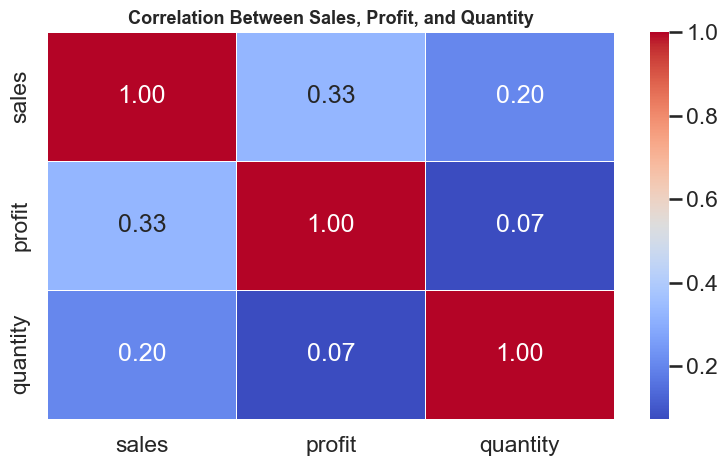

In [18]:
# ================================
# 🔗 CORRELATION MATRIX
# ================================
corr = df[['sales', 'profit', 'quantity']].corr()

plt.figure()

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm',
    fmt=".2f",
    linewidths=0.5
)

plt.title("Correlation Between Sales, Profit, and Quantity")

plt.tight_layout()
plt.show()

## Insights
The correlation matrix shows a moderate positive relationship between sales and profit (0.33), indicating that higher sales generally lead to higher profits, but not consistently. The relationship between sales and quantity is weak (0.20), suggesting that increases in sales are not strongly driven by higher purchase volumes but likely by pricing differences. Additionally, the correlation between profit and quantity is very weak (0.07), implying that selling more units does not necessarily result in higher profitability. Overall, the weak correlations highlight that factors such as pricing, discounts, and cost structures play a more significant role than volume alone.

## Business Implications
The moderate link between sales and profit suggests that simply increasing revenue is not sufficient to ensure profitability, and greater focus should be placed on margin management. The weak relationship between quantity and both sales and profit indicates that strategies focused solely on increasing sales volume may not be effective. Instead, the business should prioritize optimizing pricing strategies, controlling costs, and reducing excessive discounting to improve profitability. A more value-driven approach, rather than volume-driven growth, will help achieve sustainable financial performance.

In [19]:
# KPI Calculations
total_sales = df['sales'].sum()
total_orders = df['order_id'].nunique()
aov = total_sales / total_orders

# Create Table
kpi_table = pd.DataFrame({
    "Metric": ["Total Sales", "Total Orders", "Average Order Value"],
    "Value": [
        f"${total_sales:,.0f}",
        f"{total_orders:,}",
        f"${aov:,.2f}"
    ]
})

kpi_table

,Metric,Value
0,Total Sales,"$1,565,804"
1,Total Orders,"3,003"
2,Average Order Value,$521.41


In [20]:
# ================================
# 🧪 STATISTICAL TESTS
# ================================
from scipy.stats import ttest_ind, f_oneway

# 🔹 T-test: Returns vs No Returns
profit_returned = df[df["returns"] == 1]["profit"]
profit_not_returned = df[df["returns"] == 0]["profit"]

t_stat, p_value = ttest_ind(profit_returned, profit_not_returned, nan_policy="omit")

print("T-test (Returns vs Profit): ")
print("t-stat:", t_stat)
print("p-value:", p_value)

# 🔹 ANOVA: Profit across Regions
regions = df["region"].unique()
grouped_data = [df[df["region"] == r]["profit"] for r in regions]

anova_stat, anova_p = f_oneway(*grouped_data)

print("ANOVA (Region vs Profit):")
print("F-stat:", anova_stat)
print("p-value:", anova_p)

T-test (Returns vs Profit): 
t-stat: 1.612299796358498
p-value: 0.10695021165277682
ANOVA (Region vs Profit):
F-stat: 1.0350613934628052
p-value: 0.37577290970336313


## Insights
The statistical tests indicate that there is no significant difference in profit between returned and non-returned orders (p-value ≈ 0.107 > 0.05), suggesting that returns do not have a meaningful impact on profitability. This supports the earlier return rate analysis, where differences across categories were relatively small, indicating that returns are not a primary driver of profit variation.

Similarly, the ANOVA results show no significant difference in profit across regions (p-value ≈ 0.376 > 0.05). While the sales distribution chart highlighted strong regional differences in revenue, this finding confirms that those differences do not translate into significant profit variation, reinforcing the idea that margins and cost structures are relatively consistent across regions.

## Business Implications
Since returns do not significantly affect profitability, the business should avoid over-prioritizing return reduction as a core profit strategy and instead focus on more impactful factors such as pricing, discount control, and cost efficiency—aligning with earlier findings from the sales vs profit analysis, which showed inconsistent profitability despite higher sales.

Furthermore, although certain regions generate higher sales, the lack of significant profit differences implies that improving regional profitability may not require location-specific strategies. Instead, the business should prioritize optimizing overall margin performance and operational efficiency across all regions, while leveraging high-performing regions primarily for revenue expansion rather than profit correction.

In [21]:
# ================================
# 📌 16. SAVE RESULTS
# ================================

sales_by_region.to_csv("sales_by_region.csv")
profit_by_category.to_csv("profit_by_category.csv")

## Conclusion
Overall, the business demonstrates strong sales growth but faces challenges in maintaining consistent profitability. The analysis highlights the need to focus on margin optimization, cost control, and strategic product management. Addressing loss-making sub-categories while scaling high-performing segments will be critical for sustainable growth.

## Key Recommendations
1. Focus on high-margin categories (Technology)
2. Reduce losses in specific sub-categories (Binders, Tables, Machines)
3. Improve pricing and discount strategies